<a href="https://colab.research.google.com/github/BartolomeoML/Lesson_6/blob/main/Lesson_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import re
import urllib.request
import sqlite3
from datetime import datetime

# Ссылка на датасет
LOG_URL = "https://raw.githubusercontent.com/BartolomeoML/Lesson_6/refs/heads/main/nginx_log_300.000.txt"

# Скачиваем лог-файл в память
print("Загрузка лог-файла...")
with urllib.request.urlopen(LOG_URL) as response:
    log_content = response.read().decode('utf-8')
log_lines = log_content.strip().split('\n')
print(f"Загружено строк: {len(log_lines)}")

# Подключаемся к SQLite
conn = sqlite3.connect('nginx_logs.db')
cursor = conn.cursor()

cursor.execute('''
CREATE TABLE IF NOT EXISTS web_logs (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    ip TEXT,
    datetime TEXT,          -- дата сохраняется в ISO формате: YYYY-MM-DD HH:MM:SS
    method TEXT,            -- GET, POST и т.д.
    request_path TEXT,      -- путь (/image/..., /product/...)
    protocol TEXT,          -- HTTP/1.1 и т.д.
    status INTEGER,         -- код ответа (200, 404)
    size INTEGER,           -- объем переданных данных
    referer TEXT,           -- источник перехода
    user_agent TEXT,        -- полный юзер-агент
    os TEXT,                -- выделенная ОС (Windows, Android, Linux, iOS, Unknown)
    browser_or_bot TEXT     -- выделенный браузер или бот (Chrome, Googlebot, bingbot и др.)
)
''')
conn.commit()


def convert_to_iso_datetime(raw_date_str):
    """
    Преобразует дату из формата Nginx '22/Jan/2019:03:56:14 +0330'
    в стандартный формат ISO '2019-01-22 03:56:14'.
    """
    try:
        # Отсекаем часовой пояс
        clean_date = raw_date_str.split(' ')[0]
        # Парсим строку в объект datetime
        dt_obj = datetime.strptime(clean_date, "%d/%b/%Y:%H:%M:%S")
        # Возвращаем строку в формате ISO
        return dt_obj.strftime("%Y-%m-%d %H:%M:%S")
    except Exception:
        return None

# Функция для определения ОС и браузера/бота из юзер-агента
def parse_user_agent(ua_string):
    ua_lower = ua_string.lower()

    # Определяем ОС
    if 'android' in ua_lower:
        os_name = 'Android'
    elif 'windows' in ua_lower:
        os_name = 'Windows'
    elif 'iphone' in ua_lower or 'ipad' in ua_lower:
        os_name = 'iOS'
    elif 'linux' in ua_lower:
        os_name = 'Linux'  # Десктопный Linux
    else:
        os_name = 'Other/Unknown'

    # Определяем браузер или бота
    if 'googlebot' in ua_lower:
        client = 'Googlebot'
    elif 'bingbot' in ua_lower:
        client = 'Bingbot'
    elif 'ahrefsbot' in ua_lower:
        client = 'AhrefsBot'
    elif 'chrome' in ua_lower:
        client = 'Chrome'
    elif 'firefox' in ua_lower:
        client = 'Firefox'
    elif 'safari' in ua_lower:
        client = 'Safari'
    else:
        client = 'Other/Unknown'

    return os_name, client

parsed_rows = []

for line in log_lines:
    try:
        # Делим строку по кавычкам
        parts = line.split('"')
        if len(parts) < 6:
            continue

        # IP и дата
        part_zero = parts[0].strip()
        ip = part_zero.split(' ')[0]

        # Вытаскиваем дату из квадратных скобок
        start_idx = part_zero.find('[')
        end_idx = part_zero.find(']')
        raw_datetime = part_zero[start_idx+1 : end_idx]

        # Конвертируем дату в формат ISO
        iso_datetime = convert_to_iso_datetime(raw_datetime)
        if not iso_datetime:
            continue  # Если дата повреждена и не сконвертировалась, пропускаем строчку

        # Запрос (метод, путь, протокол)
        request_part = parts[1].strip().split(' ')
        method = request_part[0] if len(request_part) > 0 else 'UNKNOWN'
        path = request_part[1] if len(request_part) > 1 else '/'
        protocol = request_part[2] if len(request_part) > 2 else 'HTTP/1.1'

        # Статус и размер
        status_size_part = parts[2].strip().split(' ')
        status = int(status_size_part[0]) if len(status_size_part) > 0 else 0
        size_raw = status_size_part[1] if len(status_size_part) > 1 else '0'
        size = int(size_raw) if size_raw != '-' else 0

        # Реферер и юзер-агент
        referer = parts[3]
        user_agent = parts[5]

        # Анализируем User-Agent
        os_name, client_name = parse_user_agent(user_agent)

        parsed_rows.append((
            ip, iso_datetime, method, path, protocol, status, size, referer, user_agent, os_name, client_name
        ))
    except Exception:
        # Игнорируем некорректные строки, чтобы процесс не прерывался
        continue

# 4. Массовый импорт данных в SQLite
cursor.executemany('''
INSERT INTO web_logs (ip, datetime, method, request_path, protocol, status, size, referer, user_agent, os, browser_or_bot)
VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
''', parsed_rows)

conn.commit()
print(f"Импорт завершен. Успешно записано строк в БД: {len(parsed_rows)}")

# Закрываем соединение
conn.close()

Загрузка лог-файла...
Загружено строк: 300000
Импорт завершен. Успешно записано строк в БД: 300000


In [7]:
import sqlite3
import pandas as pd

# Подключаемся к базе данных
conn = sqlite3.connect('nginx_logs.db')

def run_query(title, sql):
    """Вспомогательная функция для выполнения вывода результатов"""
    print(f"=== {title} ===")
    df = pd.read_sql_query(sql, conn)
    display(df)
    print("\n" + "="*50 + "\n")

# Сколько всего записей в базе
q_total_rows = "SELECT COUNT(*) as [Всего записей в БД] FROM web_logs"
run_query("1. Общее количество записей", q_total_rows)

# Сколько уникальных IP-адресов
q_unique_ips = "SELECT COUNT(DISTINCT ip) as [Уникальных IP] FROM web_logs"
run_query("2. Количество уникальных IP-адресов", q_unique_ips)

# Строки с десктопным Linux в User-Agent (Лимит 10)
q_linux_desktop = """
SELECT ip, datetime, method, request_path, status, os, browser_or_bot
FROM web_logs
WHERE os = 'Linux'
LIMIT 10
"""
run_query("3. Десктопные пользователи Linux (Лимит 10)", q_linux_desktop)

# Использование агрегатных функций (SUM, AVG, COUNT)
q_metrics = """
SELECT
    COUNT(*) as [Всего запросов],
    SUM(size) / 1024.0 / 1024.0 as [Суммарный трафик (МБ)],
    AVG(size) / 1024.0 as [Средний размер ответа (КБ)],
    COUNT(CASE WHEN status >= 400 THEN 1 END) as [Количество ошибок (4xx/5xx)]
FROM web_logs
"""
run_query("4. Общие метрики сервера (SUM, AVG, COUNT)", q_metrics)

# Почасовая статистика активности сервера
q_hourly_stats = """
SELECT
    strftime('%H', datetime) as [Час суток],
    COUNT(*) as [Количество запросов],
    COUNT(DISTINCT ip) as [Уникальных посетителей],
    ROUND(SUM(size) / 1024.0 / 1024.0, 2) as [Трафик (МБ)]
FROM web_logs
GROUP BY [Час суток]
ORDER BY [Час суток] ASC
"""
run_query("5. Почасовая статистика активности сервера", q_hourly_stats)

# Закрываем соединение
conn.close()

=== 1. Общее количество записей ===


,Всего записей в БД
0,600000




=== 2. Количество уникальных IP-адресов ===


,Уникальных IP
0,8694




=== 3. Десктопные пользователи Linux (Лимит 10) ===


,ip,datetime,method,request_path,status,os,browser_or_bot
0,91.99.72.15,2019-01-22 03:56:19,GET,/product/10075/13903/%D9%85%D8%A7%DB%8C%DA%A9%...,200,Linux,Chrome
1,91.99.72.15,2019-01-22 03:56:20,GET,/product/32798/63266/%DB%8C%D8%AE%DA%86%D8%A7%...,200,Linux,Chrome
2,91.99.72.15,2019-01-22 03:56:21,GET,/product/7793/9663/%D9%85%D8%A7%DB%8C%DA%A9%D8...,200,Linux,Chrome
3,91.99.72.15,2019-01-22 03:56:34,GET,/product/29080?model=58289,200,Linux,Chrome
4,91.99.72.15,2019-01-22 03:57:23,GET,/product/7073/8523/%D9%85%D8%AE%D9%84%D9%88%D8...,200,Linux,Chrome
5,91.99.72.15,2019-01-22 03:57:24,GET,/product/13912/23584/%DA%86%D8%A7%DB%8C-%D8%B3...,200,Linux,Chrome
6,91.99.72.15,2019-01-22 03:57:25,GET,/product/4031/20/%D8%B3%DB%8C%D9%86%DA%A9-%D8%...,200,Linux,Chrome
7,91.99.72.15,2019-01-22 03:58:11,GET,/product/31675/61782/%D9%85%D8%A7%DB%8C%DA%A9%...,200,Linux,Chrome
8,91.99.72.15,2019-01-22 03:58:32,GET,/product/7570?model=9258,200,Linux,Chrome
9,91.99.72.15,2019-01-22 03:59:10,GET,/product/29146?model=58399,200,Linux,Chrome




=== 4. Общие метрики сервера (SUM, AVG, COUNT) ===


,Всего запросов,Суммарный трафик (МБ),Средний размер ответа (КБ),Количество ошибок (4xx/5xx)
0,600000,7675.489628,13.099502,8526




=== 5. Почасовая статистика активности сервера ===


,Час суток,Количество запросов,Уникальных посетителей,Трафик (МБ)
0,03,2570,116,45.30
1,04,28942,767,581.60
2,05,29734,762,615.14
3,06,38714,1263,688.08
4,07,95600,2149,1223.27
5,08,191532,2932,2123.13
6,09,212908,2960,2398.96


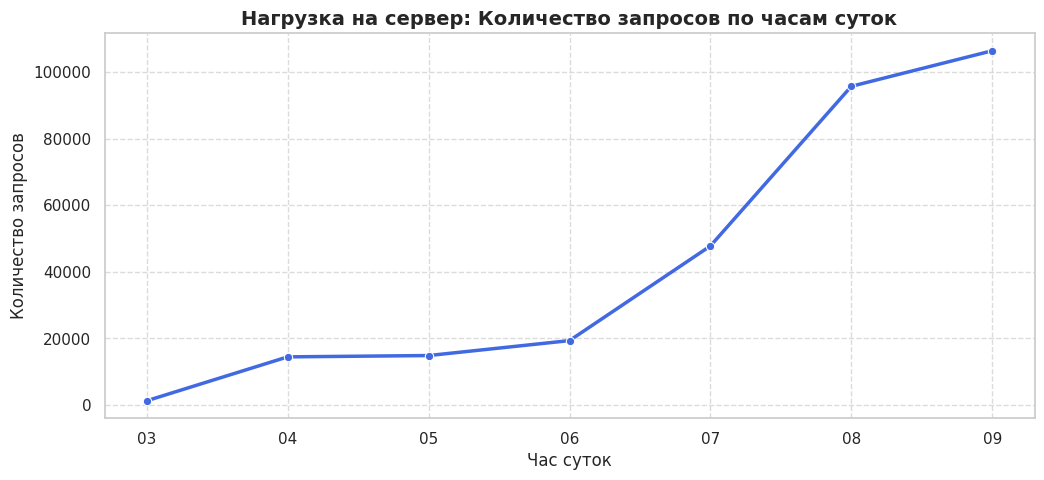

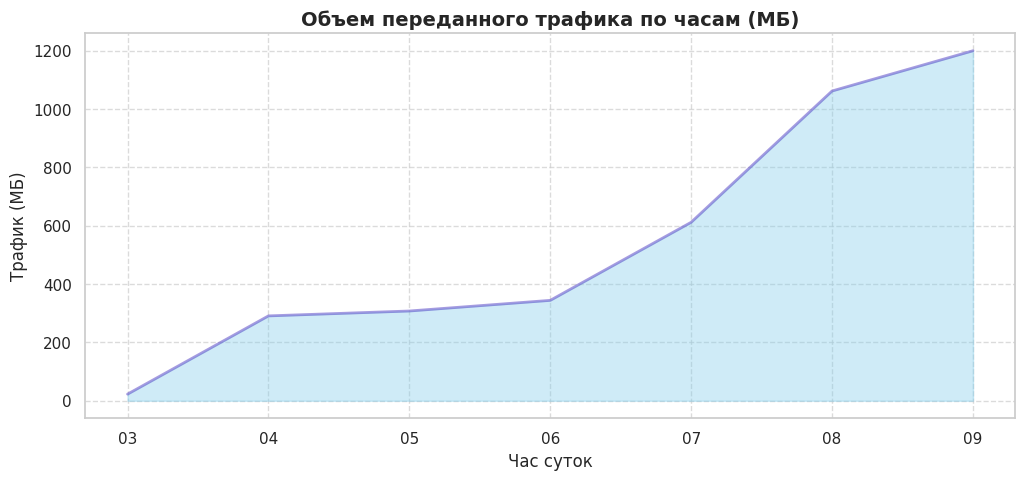

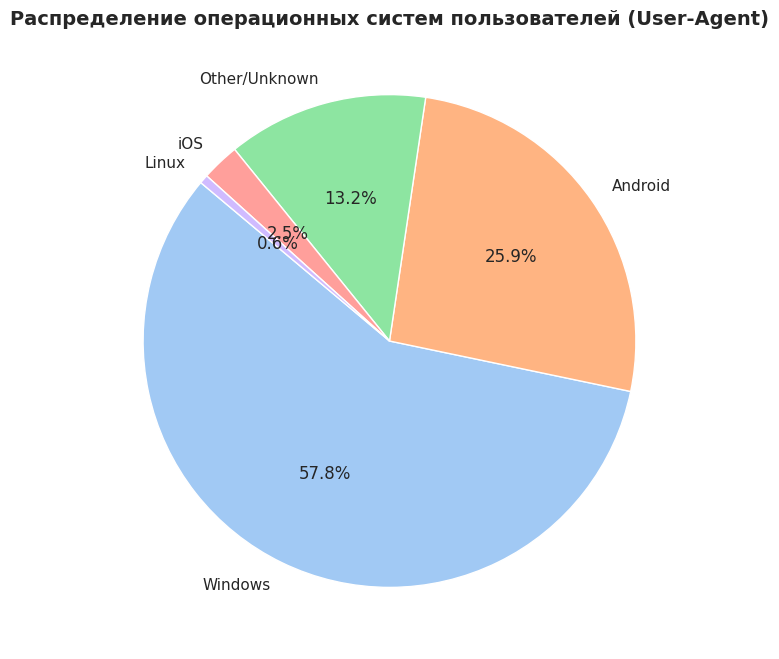

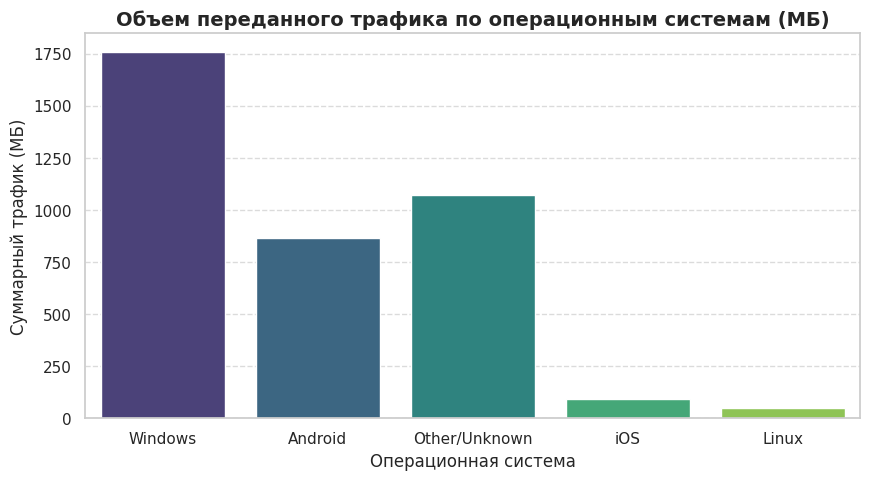

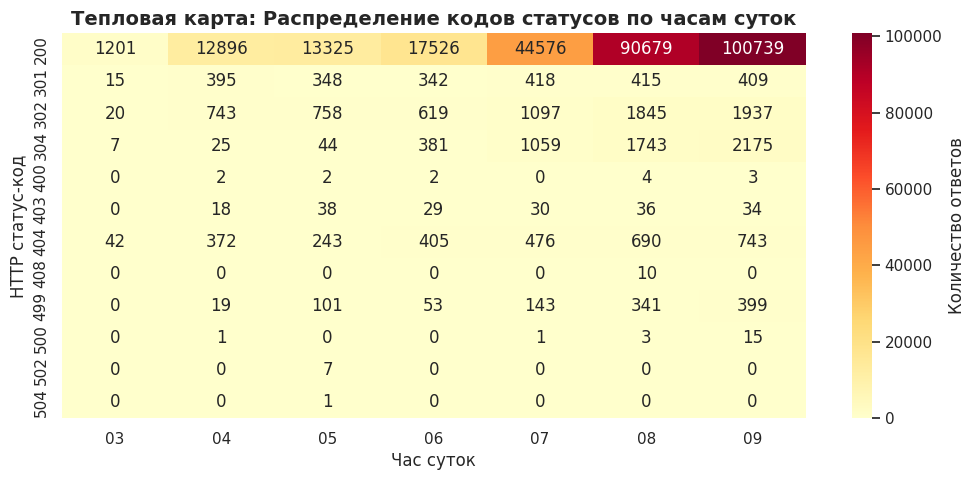

In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля для графиков
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# Подключаемся к базе данных
conn = sqlite3.connect('nginx_logs.db')

# Запрос для почасовой статистики (запросы и трафик)
df_hourly = pd.read_sql_query("""
    SELECT
        strftime('%H', datetime) as hour,
        COUNT(*) as requests,
        SUM(size) / 1024.0 / 1024.0 as traffic_mb
    FROM web_logs
    GROUP BY hour
    ORDER BY hour
""", conn)

# Запрос для анализа операционных систем (количество и трафик)
df_os = pd.read_sql_query("""
    SELECT
        os,
        COUNT(*) as requests,
        SUM(size) / 1024.0 / 1024.0 as traffic_mb
    FROM web_logs
    GROUP BY os
    ORDER BY requests DESC
""", conn)

# Запрос для графика количества статус-кодов по часам
df_status_hourly = pd.read_sql_query("""
    SELECT
        strftime('%H', datetime) as hour,
        status,
        COUNT(*) as count
    FROM web_logs
    GROUP BY hour, status
""", conn)

conn.close()

# Почасовая активность (Количество запросов по часам)
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_hourly, x='hour', y='requests', marker='o', color='royalblue', linewidth=2.5)
plt.title('Нагрузка на сервер: Количество запросов по часам суток', fontsize=14, fontweight='bold')
plt.xlabel('Час суток')
plt.ylabel('Количество запросов')
plt.xticks(df_hourly['hour'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Объем трафика по часам за исследуемый период
plt.figure(figsize=(12, 5))
# Строим график с заполнением области под линией (Area Chart)
plt.fill_between(df_hourly['hour'], df_hourly['traffic_mb'], color="skyblue", alpha=0.4)
plt.plot(df_hourly['hour'], df_hourly['traffic_mb'], color="Slateblue", alpha=0.6, linewidth=2)
plt.title('Объем переданного трафика по часам (МБ)', fontsize=14, fontweight='bold')
plt.xlabel('Час суток')
plt.ylabel('Трафик (МБ)')
plt.xticks(df_hourly['hour'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Распределение операционных систем (Pie Chart)
plt.figure(figsize=(8, 8))
# Для круговой диаграммы используем стандартный matplotlib
colors = sns.color_palette('pastel')[0:5]
plt.pie(df_os['requests'], labels=df_os['os'], autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Распределение операционных систем пользователей (User-Agent)', fontsize=14, fontweight='bold')
plt.show()

# Объемы трафика по разным операционным системам (Bar Plot)
plt.figure(figsize=(10, 5))
sns.barplot(data=df_os, x='os', y='traffic_mb', hue='os', palette='viridis', legend=False)
plt.title('Объем переданного трафика по операционным системам (МБ)', fontsize=14, fontweight='bold')
plt.xlabel('Операционная система')
plt.ylabel('Суммарный трафик (МБ)')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

# Тепловая карта кодов ответов по часам. Преобразуем данные в сводную таблицу (pivot table) для построения тепловой карты
pivot_status = df_status_hourly.pivot(index='status', columns='hour', values='count').fillna(0)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_status, annot=True, fmt=".0f", cmap="YlOrRd", cbar_kws={'label': 'Количество ответов'})
plt.title('Тепловая карта: Распределение кодов статусов по часам суток', fontsize=14, fontweight='bold')
plt.xlabel('Час суток')
plt.ylabel('HTTP статус-код')
plt.show()